## Regularization - Weights & Biases decay
The goal of this notebook is to test the effect of regularization, in terms of weight and bias decay, on the performance of the SGD optimizer on a linear regression problem.
We will use a synthetic dataset generated with `make_regression`, an ill-conditioned (`RANK`-effective rank) signal of `IN_FEATURE` predictors and `OUT_FEATURE` targets, to produce several independent noisy realizations of the same underlying relationship.

# Training: decay in isolation

This experiment comprises two scenarios:
In every scenario the underlying ill-conditioned signal and the noise level are the same across `N_TRIALS`; what changes between trials is only the specific noisy realization drawn.

1. No weight decay
   - `N_TRIALS` independent noisy realizations of the same underlying signal, trained without any regularization

2. Weight decay:
   - `N_TRIALS` independent noisy realizations of the same underlying signal
   - a swept dimension of weight decay coefficients, to observe how weight decay shrinks and stabilizes the learned weights and biases

# 1. No weight decay

In this scenario we train the model without any weight decay, on several
independent noisy realizations of the same signal drawn at a fixed noise
level, and evaluate its performance on the test set. We use a learning rate
scheduler and the SGD optimizer.
We also plot the training and validation loss curves to visualize the performance of the model.

In [11]:
"""Common hyper parameters across scenarios"""
SEED = 888
BATCH_SIZE = 16
SAMPLE_SIZE = 200
NOISE = 100
EPOCHS = 1000
N_TRIALS = 4
EVAL_STEP = 10
RANK = 5
IN_FEATURE, OUT_FEATURE = 18, 2
SPLIT_RATIO = 0.9
MAX_LR, MIN_LR = 1e-2, 1e-4

assert RANK < IN_FEATURE

In [12]:
"""Training over N_TRIALS independent ill-conditioned realizations (RANK-effective, IN_FEATURE predictors) of the same underlying structure, one trainer fitting each, to observe how weights and biases vary with a high variance dataset."""

import numpy as np
from examples.linear_regression.helpers.dataset import generate_illcond_regression_repeats, preprocess_dataloader, split_dataset
from examples.linear_regression.helpers.train import create_trainer, fit_model


repeats, true_coefs = generate_illcond_regression_repeats(N_TRIALS, SAMPLE_SIZE, IN_FEATURE, OUT_FEATURE, RANK, 0.01, NOISE, SEED)
train_samples, test_samples = split_dataset(repeats, split_ratio=SPLIT_RATIO, axis=1)

fitted_trainers = []
for A_tr, A_te in zip(train_samples, test_samples):
    print(f"Condition Number: {np.linalg.cond(np.vstack([A_tr, A_te]))}")

    loader_tr, loader_te = preprocess_dataloader(A_tr, A_te, BATCH_SIZE, OUT_FEATURE)

    trainer = create_trainer(IN_FEATURE, OUT_FEATURE, MIN_LR, MAX_LR, EPOCHS)
    fit_model(trainer, loader_tr, loader_te, EPOCHS, EVAL_STEP)

    fitted_trainers.append(trainer)


(200, 18) (200, 2)
(200, 18) (200, 2)
(200, 18) (200, 2)
(200, 18) (200, 2)


ValueError: too many values to unpack (expected 2)

## 1.1 No weight decay: Loss history

The loss histories are plotted for each trial on the same graph, with train and evaluation loss shown in separate plots.

The dashed lines represent the optimal loss values for the training and evaluation sets, respectively.

The optimal loss value is computed as `OLS`.

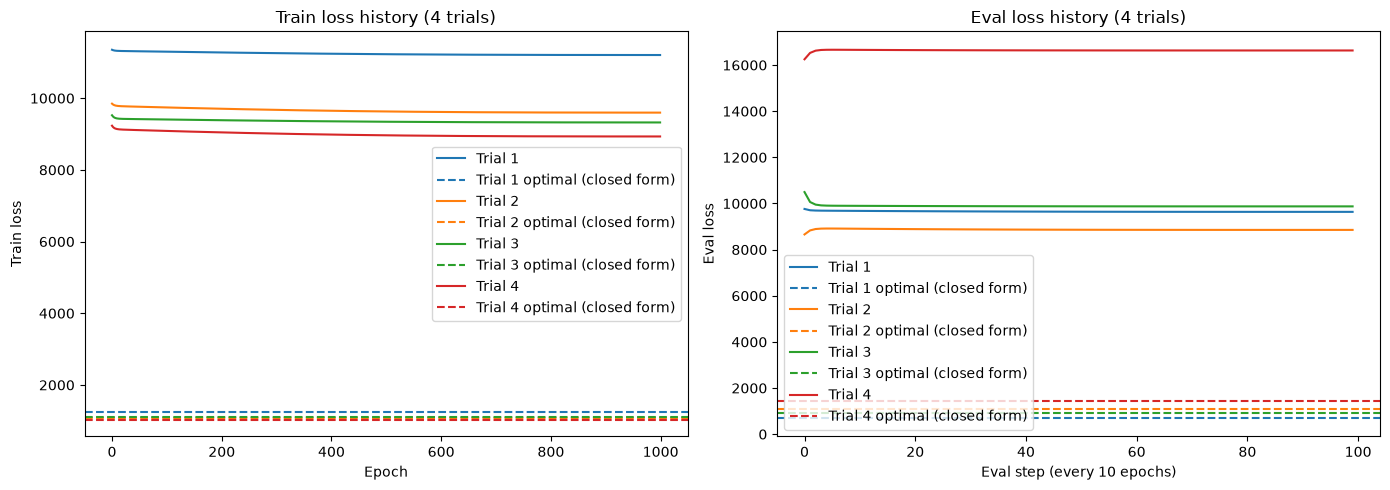

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from core.functions import mse
from examples.linear_regression.helpers.train import get_models_params


def param_magnitude(p: np.ndarray) -> float:
    """L2 norm of a weight/bias array, collapsing it to a single scalar for plotting."""
    return float(np.linalg.norm(p))

def closed_form_fit(X: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """OLS closed-form solution (W, b) minimizing mse(X @ W + b, y) on the given sample."""
    A = np.hstack([X, np.ones((X.shape[0], 1))])
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)
    return coef[:-1], coef[-1]

def closed_form_loss(sample: np.ndarray) -> float:
    """Optimal MSE achievable on `sample` via its OLS closed-form solution."""
    X, y = sample[:, :OUT_FEATURE], sample[:, OUT_FEATURE:]
    W_star, b_star = closed_form_fit(X, y)
    return float(mse(X @ W_star + b_star, y))

def plot_loss_history(ax, loss_histories: list, samples: list, xlabel: str, ylabel: str, title: str) -> None:
    """Plot each trial's loss curve, with a dashed line at its OLS-optimal (closed form) loss."""
    for i, (losses, sample) in enumerate(zip(loss_histories, samples)):
        line, = ax.plot(losses, label=f"Trial {i+1}")
        ax.axhline(closed_form_loss(sample), color=line.get_color(), linestyle="dashed", label=f"Trial {i+1} optimal (closed form)")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{title} ({N_TRIALS} trials)")
    ax.legend()


params_history = get_models_params([trainer.model for trainer in fitted_trainers])
weights_history = np.array([param_magnitude(p[0]) for p in params_history])
bias_history = np.array([param_magnitude(p[1]) for p in params_history])

fig, (ax_train, ax_eval) = plt.subplots(1, 2, figsize=(14, 5))

plot_loss_history(ax_train, [t.train_loss for t in fitted_trainers], train_samples,
                   "Epoch", "Train loss", "Train loss history")
plot_loss_history(ax_eval, [t.eval_loss for t in fitted_trainers], test_samples,
                   f"Eval step (every {EVAL_STEP} epochs)", "Eval loss", "Eval loss history")

fig.tight_layout()
plt.show()


## 1.2 Loss history interpretation

As you can see, the eval losses, don't decreas as well as the train losses, and this is because high variance in targets, produce bad generalization, and the model is not able to learn the underlying signal, but only the noise.

## 1.3 Weights and Biases interpretation

The goal of the charts below is to show how in an high variance dataset, the learned weights and biases are spread across trials.


In [ ]:

trials = np.arange(1, N_TRIALS + 1)

true_weight = np.array([param_magnitude(c) for c in true_coefs])
true_bias = np.zeros(N_TRIALS)  # make_regression defaults to a zero intercept

fig, (ax_w, ax_b) = plt.subplots(1, 2, figsize=(14, 5))

ax_w.bar(trials, weights_history)
ax_w.scatter(trials, true_weight, color="black", zorder=5, label="True weight")
ax_w.set_xticks(trials)
ax_w.set_xlabel("N_TRIALS")
ax_w.set_ylabel("Value")
ax_w.set_title(f"Learned weight across {N_TRIALS} trials")
ax_w.legend()

ax_b.bar(trials, bias_history)
ax_b.scatter(trials, true_bias, color="black", zorder=5, label="True bias")
ax_b.set_xticks(trials)
ax_b.set_xlabel("N_TRIALS")
ax_b.set_ylabel("Value")
ax_b.set_title(f"Learned bias across {N_TRIALS} trials")
ax_b.legend()

fig.suptitle(f"Weights & biases across {N_TRIALS} trials")
fig.tight_layout()
plt.show()

# 2. Weight decay

In this scenario, we train over several `N_TRIALS`, indipendent noisy realization of the same underling signal, with increasing weight decay coefficient.


The goal is to show, how weight decay reduce the variance of the learned weights and biases, and how it affects the loss history.

In [ ]:
import numpy as np
from core.training.trainer import Trainer
from examples.linear_regression.helpers.dataset import generate_illcond_regression_repeats, split_dataset, preprocess_dataloader
from examples.linear_regression.helpers.train import create_trainer, fit_model


DECAY_UPTO = 2
DECAY_DISTANCE = 0.5
TOTAL_DECAY_TERMS = int(DECAY_UPTO/DECAY_DISTANCE)

decay_coefs = np.linspace(0, DECAY_UPTO, TOTAL_DECAY_TERMS)
repeats, _ = generate_illcond_regression_repeats(N_TRIALS, SAMPLE_SIZE, IN_FEATURE, OUT_FEATURE, RANK, 0.01, NOISE, SEED)
tr, te = split_dataset(repeats, split_ratio=SPLIT_RATIO, axis=1)

all_trainers:list[Trainer] = []
for sample_tr, sample_te in zip(tr, te):   
    loader_tr, loader_te = preprocess_dataloader(sample_tr, sample_te, BATCH_SIZE, OUT_FEATURE)
    
    trainers:list[Trainer] = []
    for decay in decay_coefs:
        trainer = create_trainer(IN_FEATURE, OUT_FEATURE, MIN_LR, MAX_LR, EPOCHS, decay)
        trainers.append(trainer)
        fit_model(trainer, loader_tr, loader_te, EPOCHS, EVAL_STEP)
    all_trainers.append(trainers)

## 2.1 Weights and Biases spread across decay coefficients

The goal of the chart below is to show how increasing the weight decay coefficient reduces the spread of the learned weights and biases across the `N_TRIALS` trials.

The weights are shrinked towards zero, this is the weights decay effect.

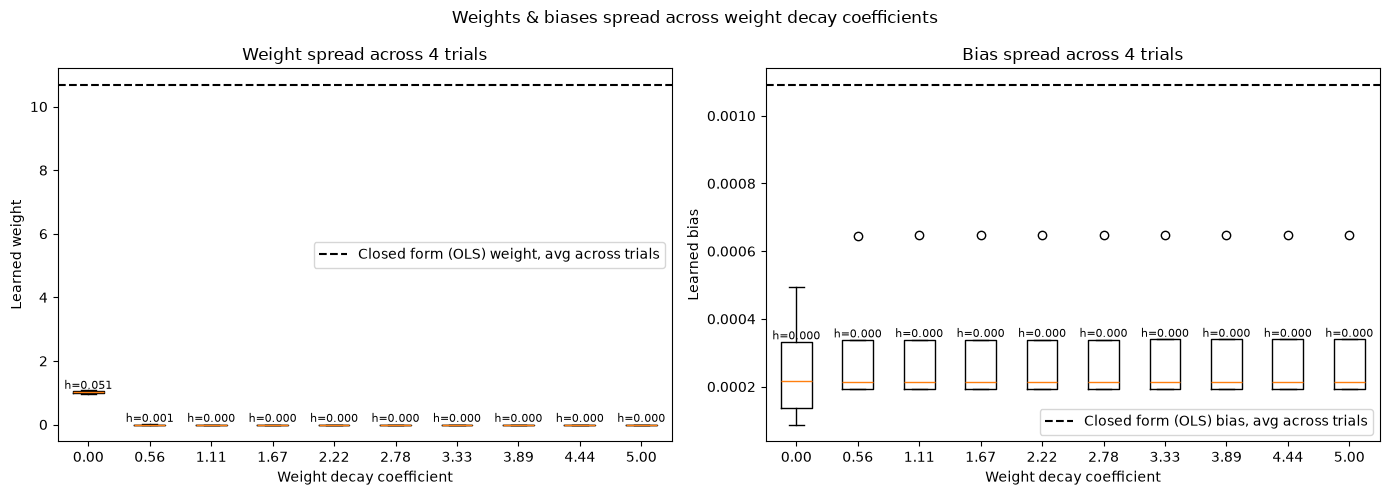

In [ ]:
from examples.linear_regression.helpers.train import get_models_params

weights_by_decay = []
bias_by_decay = []

for j in range(len(decay_coefs)):
    models = [all_trainers[i][j].model for i in range(N_TRIALS)]
    params = get_models_params(models)
    weights_by_decay.append(np.array([param_magnitude(p) for p in params[:, 0]]))
    bias_by_decay.append(np.array([param_magnitude(p) for p in params[:, 1]]))

decay_labels = [f"{decay:.2f}" for decay in decay_coefs]

closed_form_weight_ref = np.mean([param_magnitude(closed_form_fit(s[:, :OUT_FEATURE], s[:, OUT_FEATURE:])[0]) for s in tr])
closed_form_bias_ref = np.mean([param_magnitude(closed_form_fit(s[:, :OUT_FEATURE], s[:, OUT_FEATURE:])[1]) for s in tr])

def annotate_box_heights(ax, bp):
    """Label each box with its height (Q3 - Q1), so spreads can be compared at a glance."""
    for box in bp["boxes"]:
        x_data, y_data = box.get_xdata(), box.get_ydata()
        y_top, y_bottom = y_data.max(), y_data.min()
        ax.text((x_data.min() + x_data.max()) / 2, y_top, f"h={y_top - y_bottom:.3f}",
                ha="center", va="bottom", fontsize=8)

fig, (ax_w, ax_b) = plt.subplots(1, 2, figsize=(14, 5))

bp_w = ax_w.boxplot(weights_by_decay, tick_labels=decay_labels)
annotate_box_heights(ax_w, bp_w)
ax_w.axhline(closed_form_weight_ref, color="black", linestyle="dashed", label="Closed form (OLS) weight, avg across trials")
ax_w.set_xlabel("Weight decay coefficient")
ax_w.set_ylabel("Learned weight")
ax_w.set_title(f"Weight spread across {N_TRIALS} trials")
ax_w.legend()

bp_b = ax_b.boxplot(bias_by_decay, tick_labels=decay_labels)
annotate_box_heights(ax_b, bp_b)
ax_b.axhline(closed_form_bias_ref, color="black", linestyle="dashed", label="Closed form (OLS) bias, avg across trials")
ax_b.set_xlabel("Weight decay coefficient")
ax_b.set_ylabel("Learned bias")
ax_b.set_title(f"Bias spread across {N_TRIALS} trials")
ax_b.legend()

fig.suptitle("Weights & biases spread across weight decay coefficients")
fig.tight_layout()
plt.show()

## 2.2 Decay rate validation curve

The graph below shows the mean test loss across the `N_TRIALS` trials, for each decay coefficient.

The red marker is the argmin point, the sweet spot for the best decay coefficient — it is the one that produces the lowest mean test loss across trials.

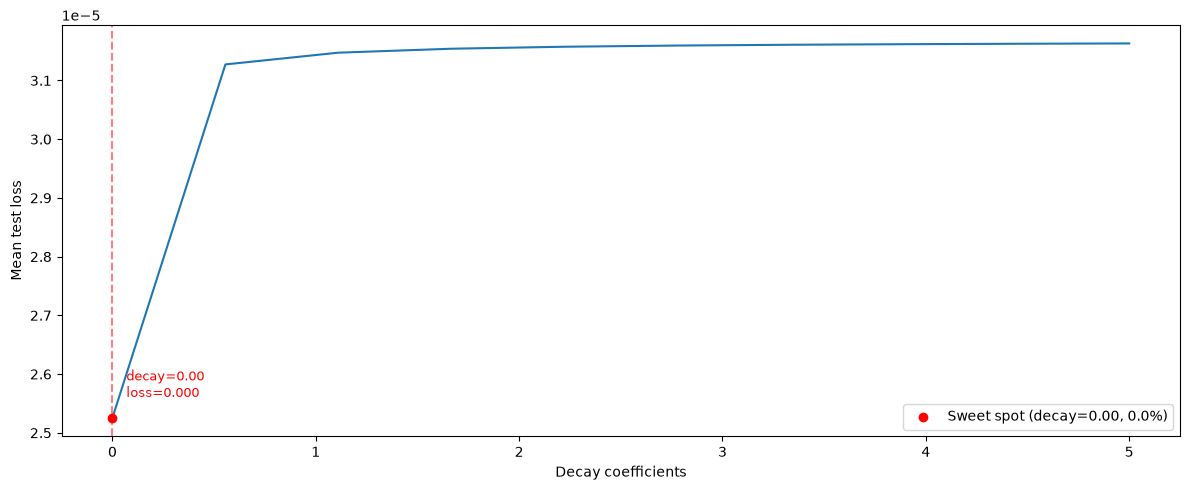

In [ ]:
import matplotlib.pyplot as plt

test_mse_decay = []
for j in range(len(decay_coefs)):
    losses = [all_trainers[i][j].eval_loss[-1] for i in range(N_TRIALS)]
    test_mse_decay.append(np.mean(losses))

best_idx = int(np.argmin(test_mse_decay))
best_decay, best_loss = decay_coefs[best_idx], test_mse_decay[best_idx]

no_decay_loss = test_mse_decay[0]
improvement_pct = (no_decay_loss - best_loss) / no_decay_loss * 100

fig, ax = plt.subplots(1, 1, figsize=(12, 5))

ax.plot(decay_coefs, test_mse_decay)
ax.scatter([best_decay], [best_loss], color="red", zorder=5, label=f"Sweet spot (decay={best_decay:.2f}, {improvement_pct:.1f}%)")
ax.axvline(best_decay, color="red", linestyle="dashed", alpha=0.5)
ax.annotate(f"decay={best_decay:.2f}\nloss={best_loss:.3f}",
            xy=(best_decay, best_loss), xytext=(10, 15), textcoords="offset points",
            fontsize=9, color="red")
ax.set_ylabel("Mean test loss")
ax.set_xlabel(f"Decay coefficients")
ax.legend()

fig.tight_layout()
plt.show()